In [ ]:
## Using data from Sergeev et al. (2025)

## In this notebook we:
## 1. Load the cubes list for TRAPPIST-1e with 2 bar surface pressure (by using the first point in the vertical air pressure array)
## 2. Create a global surface temperature map
## 3. Constrain the dayside and take a zonal average for air temperature
## 4. Plot a temperature profile w.r.t altitude
## (4.1. Ignore the interpolation business in the profile, we only care about the shape)

In [1]:
import iris
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import iris.plot as iplt
import iris.quickplot as qplt
import iris.analysis.cartography
import iris.analysis
import aeolus
import aeolus.coord

In [2]:
twobar = iris.load('/data/cluster4/jj22956/thunderstruck_files/thunderstruck-hab1_2bar-m09.nc?download=1')
air_tempp = twobar[6]
air_tempp

/home/jj22956/.local/lib/python3.12/site-packages/iris/common/mixin.py:206: FutureWarning: You are using legacy date precision for Iris units - max precision is seconds. In future, Iris will use microsecond precision - available since cf-units version 3.3 - which may affect core behaviour. To opt-in to the new behaviour, set `iris.FUTURE.date_microseconds = True`.
  warnings.warn(message, category=FutureWarning)


<iris 'Cube' of air_temperature / (K) (model_level_number: 50; latitude: 1920; longitude: 2560)>

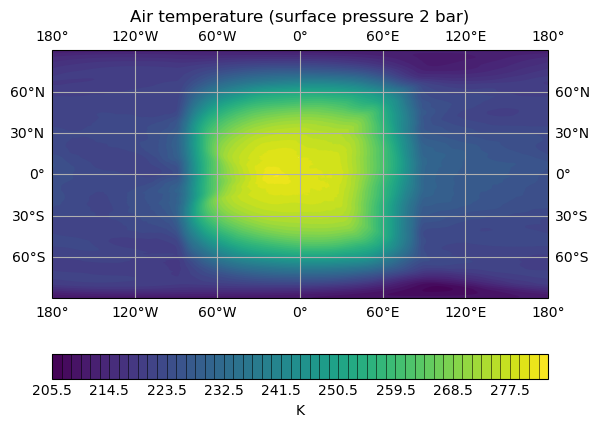

In [3]:
qplt.contourf(air_tempp[0], 50)

plt.gca().gridlines(draw_labels=True)
plt.title('Air temperature (surface pressure 2 bar)')
plt.show()

In [4]:
air_tempp_roll = aeolus.coord.roll_cube_pm180(air_tempp, add_shift=0)
air_tempp_roll[0].ndim
air_tempp_roll0 = air_tempp_roll[0]

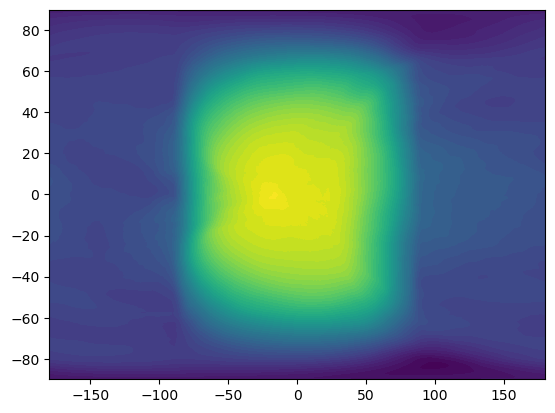

In [5]:
# contour = iplt.contour(air_tempp_roll[0])

x = air_tempp_roll0.coord('longitude').points
y = air_tempp_roll0.coord('latitude').points

data = air_tempp_roll0.data

X, Y = np.meshgrid(x, y)

plt.contourf(x, y, data, 50)

# plt.gca().gridlines(draw_labels=True)
plt.show()

In [6]:
dayside = air_tempp_roll.extract(iris.Constraint(longitude=lambda v:  (-75<= v <= 75)))
# dayside.ndim

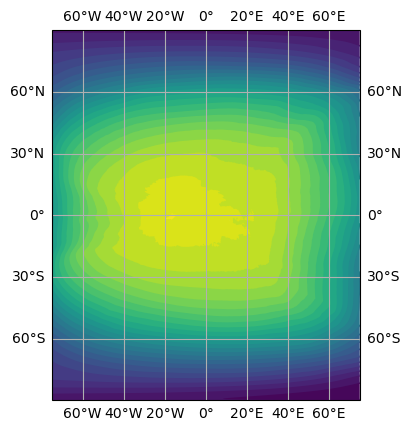

In [7]:
iplt.contourf(dayside[0], 25)

plt.gca().gridlines(draw_labels=True)
plt.show()

In [8]:
# dayside.coord('latitude').guess_bounds()
# dayside.coord('longitude').guess_bounds()
# grid_areas = iris.analysis.cartography.area_weights(dayside)

In [9]:
new_dayside = dayside.collapsed(['longitude', 'latitude'], iris.analysis.MEAN)

/home/jj22956/.local/lib/python3.12/site-packages/iris/cube.py:4447: IrisUserWarning: Collapsing spatial coordinate 'latitude' without weighting
  warnings.warn(
/home/jj22956/.local/lib/python3.12/site-packages/iris/coords.py:2258: IrisVagueMetadataWarning: Cannot check if coordinate is contiguous: Invalid operation for 'latitude', with 0 bound(s). Contiguous bounds are only defined for 1D coordinates with 2 bounds. Metadata may not be fully descriptive for 'latitude'. Ignoring bounds.
  warnings.warn(
/home/jj22956/.local/lib/python3.12/site-packages/iris/coords.py:2258: IrisVagueMetadataWarning: Cannot check if coordinate is contiguous: Invalid operation for 'longitude', with 0 bound(s). Contiguous bounds are only defined for 1D coordinates with 2 bounds. Metadata may not be fully descriptive for 'longitude'. Ignoring bounds.
  warnings.warn(


In [10]:
print(new_dayside.coord('level_height').points)

[   22.08609881    58.8992102    110.43048954   176.68879232
   257.67410042   353.37758464   463.80806964   588.96555544
   728.84127171   883.44391629  1052.77367038  1236.82151904
  1435.59638662  1649.09831841  1877.31843537  2120.26548063
  2377.93949951  2650.33179417  2937.45110773  3239.297259
  3555.86204846  3887.15349442  4233.17195929  4593.90883583
  4969.37214238  5359.56287554  5764.47152207  6184.10714221
  6618.47064199  7067.55160212  7531.35998887  8009.90350345
  8503.19165911  9011.2779113   9534.24244318 10072.25966443
 10625.57782576 11194.5960309  11779.89504149 12382.27986022
 13002.86353806 13643.13965624 14305.05933829 14991.1168694
 15704.47971086 16449.09812906 17229.86918589 18052.74500862
 18924.94253464 19855.10297164]


In [11]:
sample_points = [('level_height', np.linspace(400, 1250, 10))]
new_column = new_dayside.interpolate(sample_points, iris.analysis.Linear())

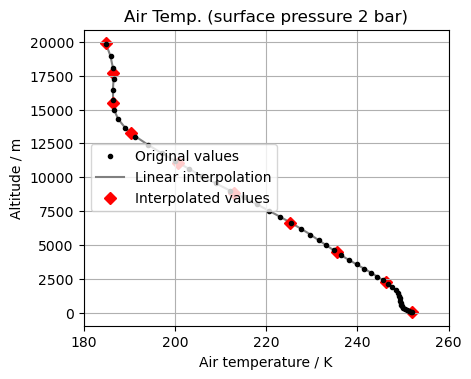

In [12]:
alt_coord = new_dayside.coord("level_height")

# Interpolate the "perfect" linear interpolation. Really this is just
# a high number of interpolation points, in this case 1000 of them.
altitude_points = [
    (
        "level_height",
        np.linspace(min(alt_coord.points), max(alt_coord.points), 1000),
    )
]
scheme = iris.analysis.Linear()
linear_column = new_dayside.interpolate(altitude_points, scheme)

# Now interpolate the data onto 10 evenly spaced altitude levels,
# as we did in the example.
altitude_points = [("level_height", np.linspace(22, 19900, 10))]
scheme = iris.analysis.Linear()
new_column = new_dayside.interpolate(altitude_points, scheme)

plt.figure(figsize=(5, 4), dpi=100)

# Plot the black markers for the original data.
qplt.plot(
    new_dayside,
    marker="o",
    color="black",
    linestyle="",
    markersize=3,
    label="Original values",
    zorder=2,
)

# Plot the gray line to display the linear interpolation.
qplt.plot(
    linear_column,
    color="gray",
    label="Linear interpolation",
    zorder=0,
)

# Plot the red markers for the new data.
qplt.plot(
    new_column,
    marker="D",
    color="red",
    linestyle="",
    label="Interpolated values",
    zorder=1,
)

ax = plt.gca()
# Space the plot such that the labels appear correctly.
plt.subplots_adjust(left=0.17, bottom=0.14)

# Limit the plot to a maximum of 5 ticks.
ax.xaxis.get_major_locator().set_params(nbins=5)

# Prevent matplotlib from using "offset" notation on the xaxis.
ax.xaxis.get_major_formatter().set_useOffset(False)

# Put some space between the line and the axes.
ax.margins(0.05)

# Place gridlines and a legend.
ax.grid()
plt.legend(loc="center left")
plt.title('Air Temp. (surface pressure 2 bar)')
plt.ylabel('Altitude / m')
plt.xlim(180, 260)
plt.show()